In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

LOADING THE DATASET


In [2]:
#CREATING DATABASE CONNECTION
conn = sqlite3.connect('inventory.db')

#FETCHING VENDOR SUMMARY DATA
df = pd.read_sql_query("select * from vendor_sales_summary", conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,0,0,0,0,68601.68
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,0,0,0,0,144929.24
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,0,0,0,0,123780.22
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,0,0,0,0,257032.07
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,0,0,0,0,257032.07


Exploratory Data Analysis

• Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.

• In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.

In [3]:
#summary statistics
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.00,3951.0000,7153.000,9552.0000,201359.00
Brand,10692.0,18039.228769,12662.187074,58.00,5793.5000,18761.500,25514.2500,90631.00
PurchasePrice,10692.0,24.385303,109.269375,0.36,6.8400,10.455,19.4825,5681.81
ActualPrice,10692.0,35.643671,148.246016,0.49,10.9900,15.990,28.9900,7499.99
Volume,10692.0,847.360550,664.309212,50.00,750.0000,750.000,750.0000,20000.00
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.00,36.0000,262.000,1975.7500,337660.00
TotalPurchaseDollars,10692.0,30106.693372,123067.799627,0.71,453.4575,3655.465,20738.2450,3811251.60
TotalSalesQuantity,10692.0,0.000000,0.000000,0.00,0.0000,0.000,0.0000,0.00
TotalSalesDollars,10692.0,0.000000,0.000000,0.00,0.0000,0.000,0.0000,0.00
TotalSalesPrice,10692.0,0.000000,0.000000,0.00,0.0000,0.000,0.0000,0.00


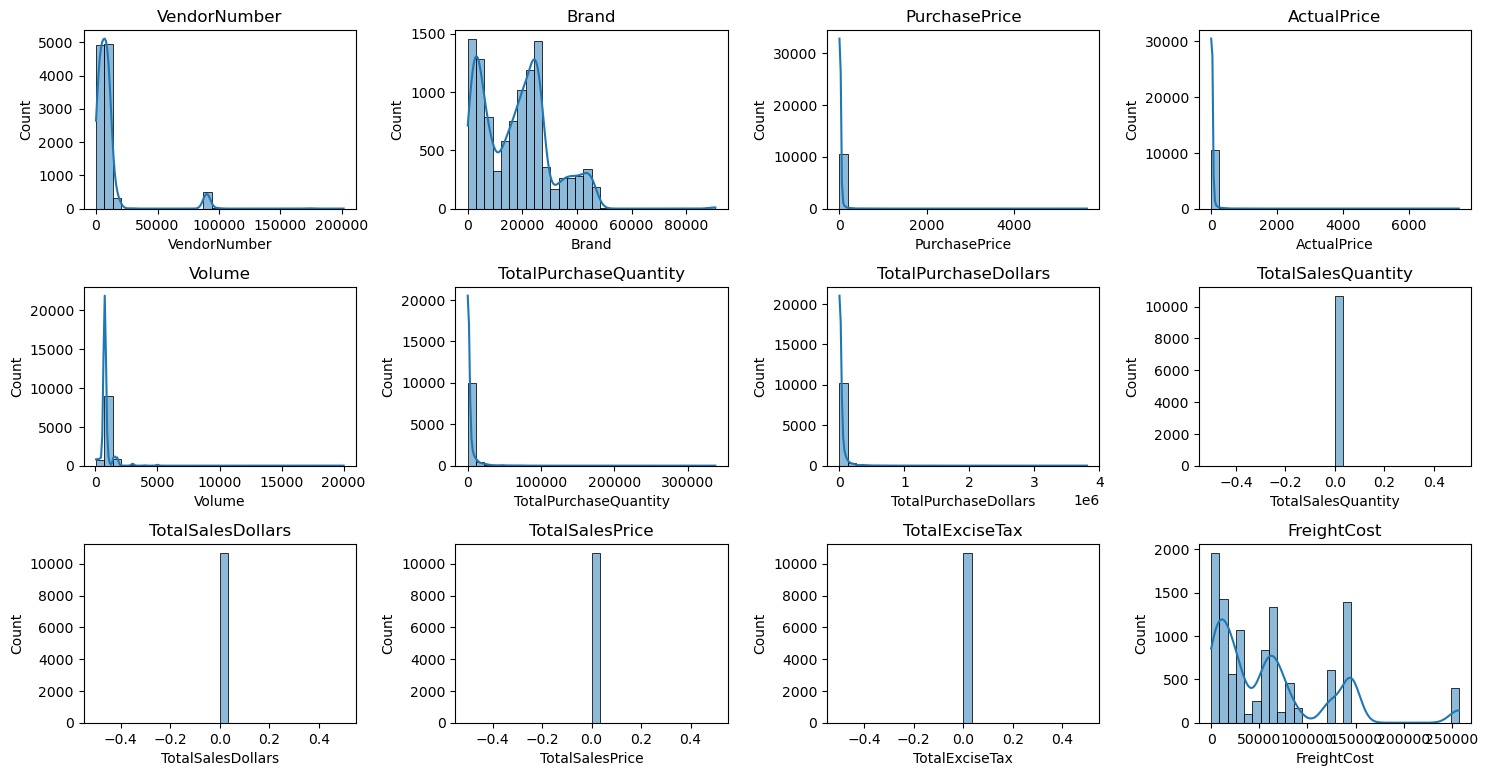

In [4]:
#Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes(include=np.number).columns

plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4,4, i+1) #Adjust grip layout as needed
    sns.histplot(df[col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

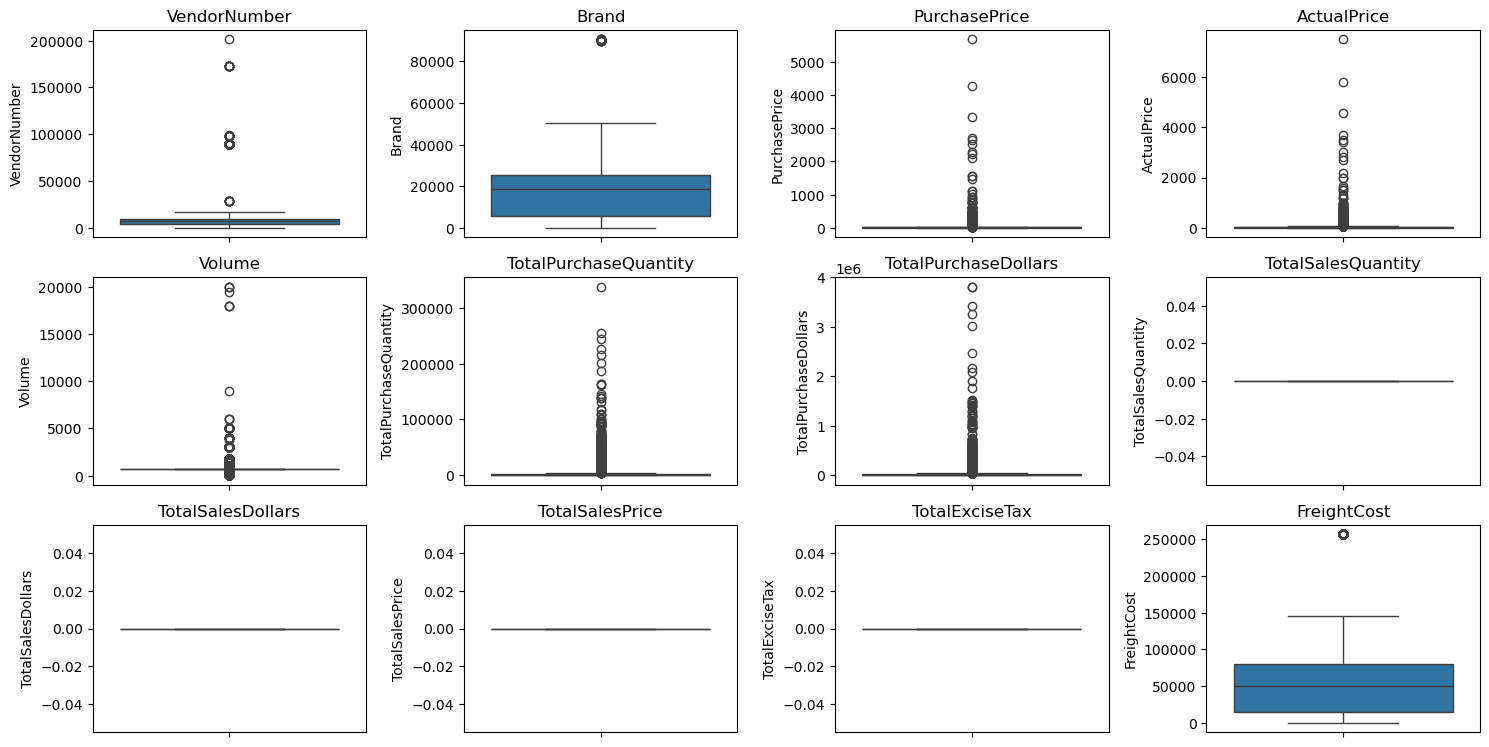

In [5]:

# Outlier Detection with Boxplots
plt.figure(figsize=(15,10))
for i, col in enumerate(numerical_cols):
    plt.subplot(4, 4, i+1)
    sns.boxplot(y = df[col])
    plt.title(col)
plt.tight_layout()
plt.show()

Summary Statistics Insights:


Negative & Zero Values:

⦁Gross Profit: Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price..

⦁Profit Margin: Has a minimum of -∞, which suggests cases where revenue is zero or even lower than costs.

⦁Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

Outliers Indicated by High Standard Deviations:

⦁Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.

⦁Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.

⦁Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that Sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

In [6]:
df = pd.read_sql_query("select * from vendor_sales_summary", conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost
0,1128,BROWN-FORMAN CORP,1233,Jack Daniels No 7 Black,26.27,36.99,1750.0,145080,3811251.60,0,0,0,0,68601.68
1,4425,MARTIGNETTI COMPANIES,3405,Tito's Handmade Vodka,23.19,28.99,1750.0,164038,3804041.22,0,0,0,0,144929.24
2,17035,PERNOD RICARD USA,8068,Absolut 80 Proof,18.24,24.99,1750.0,187407,3418303.68,0,0,0,0,123780.22
3,3960,DIAGEO NORTH AMERICA INC,4261,Capt Morgan Spiced Rum,16.17,22.99,1750.0,201682,3261197.94,0,0,0,0,257032.07
4,3960,DIAGEO NORTH AMERICA INC,3545,Ketel One Vodka,21.89,29.99,1750.0,138109,3023206.01,0,0,0,0,257032.07


In [7]:
# Filter the data by removing inconsistencies - calculate columns in SQL
df = pd.read_sql_query("""SELECT *,
    (TotalSalesDollars - TotalPurchaseDollars) AS GrossProfit,
    ((TotalSalesDollars - TotalPurchaseDollars) / TotalSalesDollars * 100) AS ProfitMargin,
    (TotalSalesQuantity / TotalPurchaseQuantity) AS StockTurnover,
    (TotalSalesDollars / TotalPurchaseDollars) AS SalesToPurchaseRatio
FROM vendor_sales_summary
WHERE (TotalSalesDollars - TotalPurchaseDollars) > 0
AND ((TotalSalesDollars - TotalPurchaseDollars) / TotalSalesDollars * 100) > 0
AND TotalSalesQuantity > 0""", conn)

In [8]:
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,Volume,TotalPurchaseQuantity,TotalPurchaseDollars,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,FreightCost,GrossProfit,ProfitMargin,StockTurnover,SalesToPurchaseRatio


<function matplotlib.pyplot.show(close=None, block=None)>

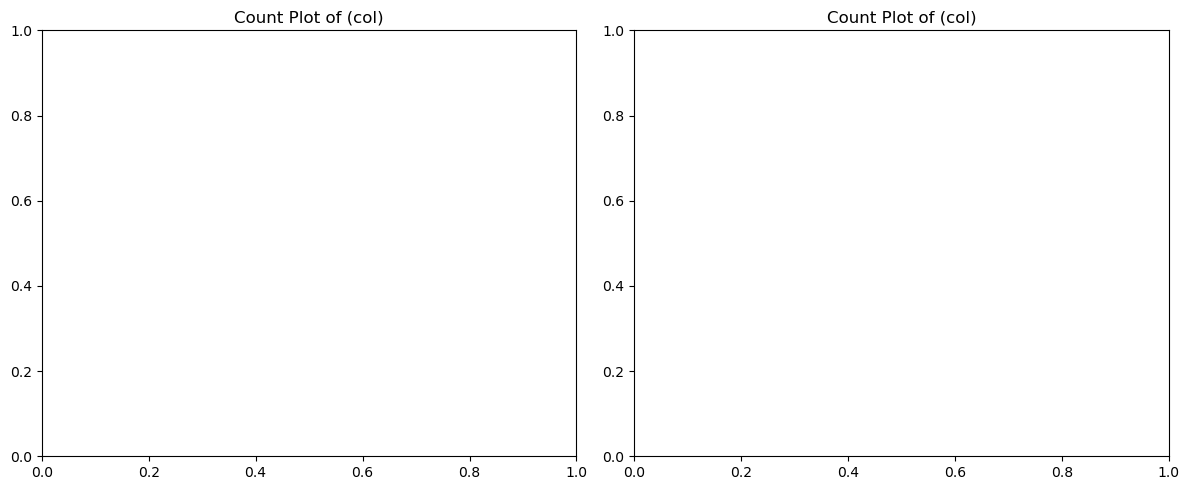

In [9]:

#Count Plots for categorical Columns
categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))
for i, col in enumerate(categorical_cols):
    plt.subplot(1, 2, i+1)
    sns.countplot(y=df[col], order=df[col].value_counts().index[:10]) #top 10 categories
    plt.title(f"Count Plot of (col)")
plt.tight_layout()
plt.show

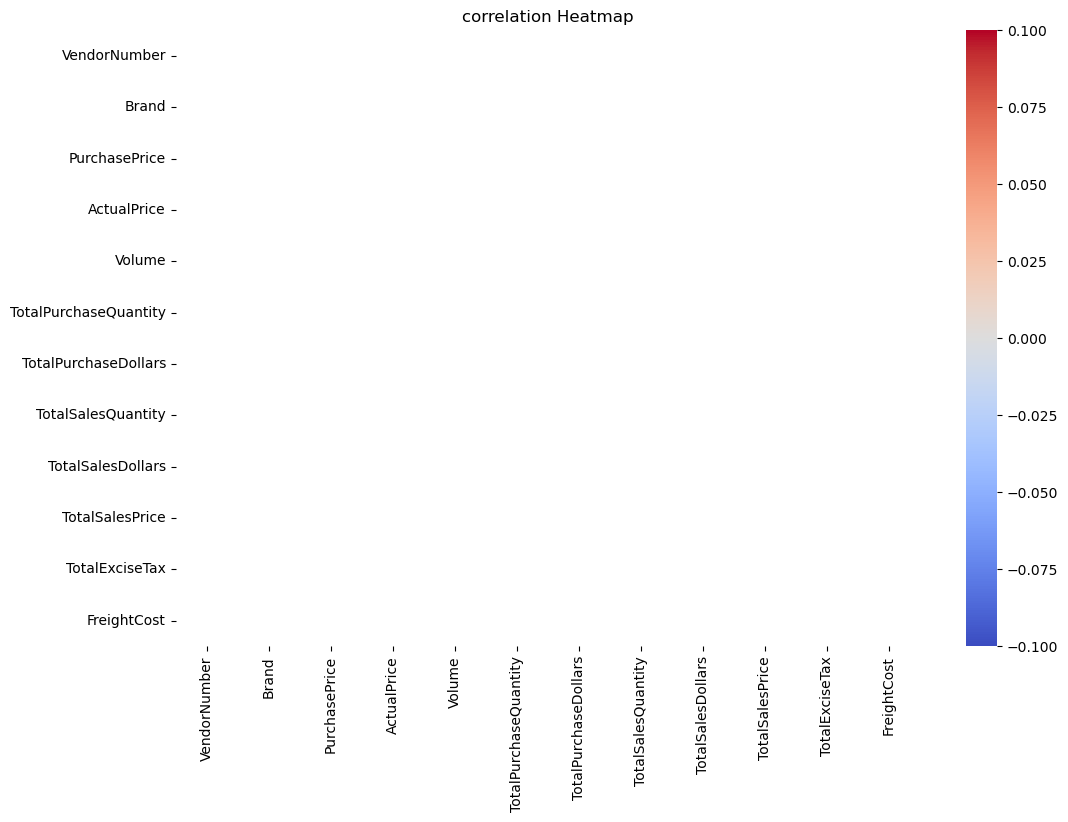

In [10]:
#Correlation Heatmap
plt.figure(figsize=(12, 8))
correlation_matrix= df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot= True, fmt=".2f", cmap="coolwarm", linewidths = 0.5)
plt.title("correlation Heatmap")
plt.show()



Correlation Insights

⦁ PurchasePrice has weak correlations with TotalSales Dollars (-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit.

⦁ Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.

⦁ Negative correlation between profit margin & total sales price (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.

⦁ Stock Turnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessarily result in higher profitability.

Data Analysis

Identify Brands that needs Promotional or Pricing Adjustments which exhibit lower sales performance but higher profit margins.

In [11]:
brand_performance = df.groupby('Description').agg({
    'TotalSalesDollars':'sum',
    'ProfitMargin': 'mean'
}).reset_index()

In [12]:

low_sales_thresold = brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_thresold = brand_performance['ProfitMargin'].quantile(0.85)

In [13]:
low_sales_thresold

np.float64(nan)

In [14]:
high_margin_thresold

np.float64(nan)

In [15]:
 #Filter brands with low sales but high profit margins
target_brands = brand_performance[
    (brand_performance['TotalSalesDollars'] <= low_sales_thresold) &
    (brand_performance['ProfitMargin'] >= high_margin_thresold)
]
print("Brands with low Sales but High Profit Margins")
display(target_brands.sort_values('TotalSalesDollars'))


Brands with low Sales but High Profit Margins


,Description,TotalSalesDollars,ProfitMargin


In [16]:
brand_performance = brand_performance[brand_performance['TotalSalesDollars']<10000] #for better vizualization

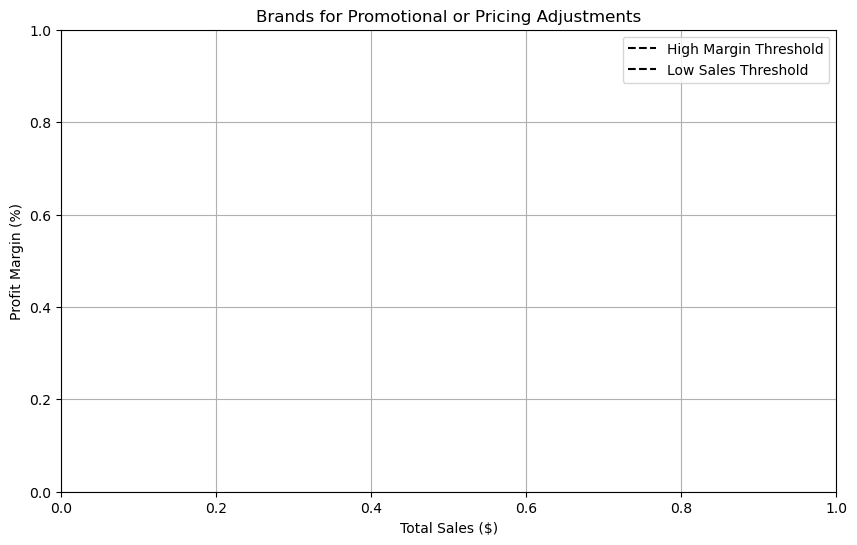

In [17]:
plt.figure(figsize= (10, 6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='ProfitMargin',color="blue", label="All Brands", alpha=0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='ProfitMargin', color='red', label="Target Brands")

plt.axhline(high_margin_thresold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_thresold, linestyle='--', color='black', label="Low Sales Threshold")

plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)
plt.show()

Which vendors and brands demonstrate the highest sales performance?

In [18]:
def format_dollars(value):
    if value >= 1_000_000:
        return f"{value/ 1_000_000:.2f}M"
    elif value >= 1_000:
        return f"{value/ 1_000:2f}K"
    else:
        return str(value)

In [19]:
df.dtypes

VendorNumber             object
VendorName               object
Brand                    object
Description              object
PurchasePrice            object
ActualPrice              object
Volume                   object
TotalPurchaseQuantity    object
TotalPurchaseDollars     object
TotalSalesQuantity       object
TotalSalesDollars        object
TotalSalesPrice          object
TotalExciseTax           object
FreightCost              object
GrossProfit              object
ProfitMargin             object
StockTurnover            object
SalesToPurchaseRatio     object
dtype: object

In [20]:
df['TotalSalesDollars'] = df['TotalSalesDollars'].astype(float)

In [21]:
# Top Vendors & Brands by sales performance
top_vendors= df.groupby("VendorName")["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description")["TotalSalesDollars"].sum().nlargest(10)
top_vendors

Series([], Name: TotalSalesDollars, dtype: float64)

In [22]:
top_brands

Series([], Name: TotalSalesDollars, dtype: float64)

In [23]:
top_brands.apply(lambda x : format_dollars(x))

Series([], Name: TotalSalesDollars, dtype: float64)

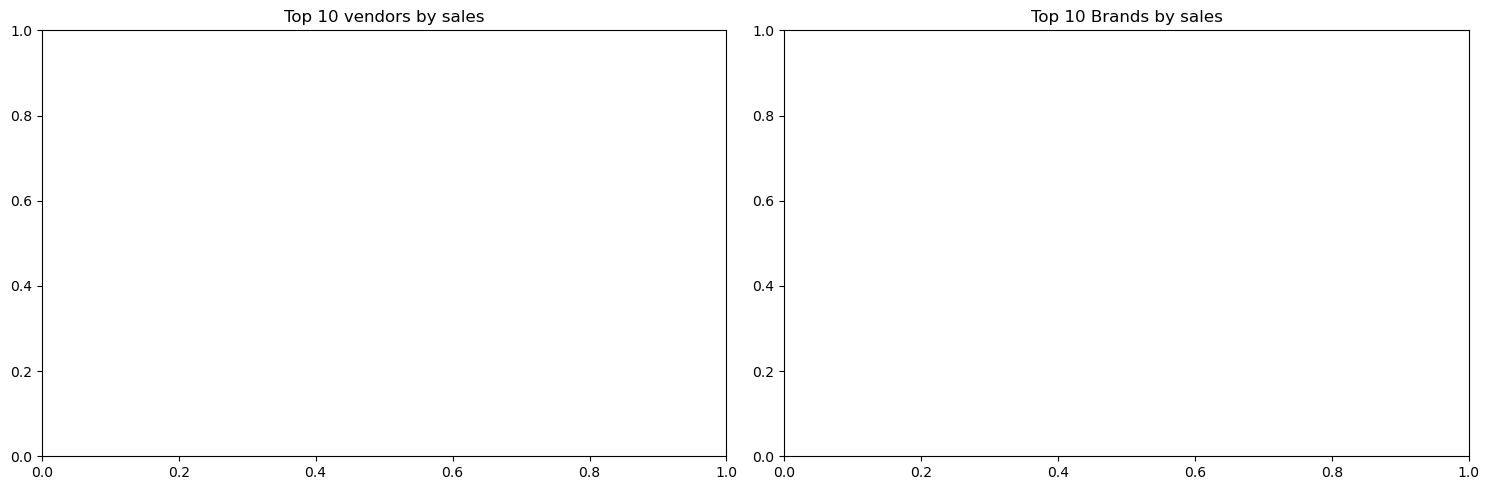

In [24]:
plt.figure(figsize=(15, 5))

#Plot for top vendors
plt.subplot(1, 2, 1)
ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 vendors by sales")

for bar in ax1.patches:
    ax1.text(bar.get_width() + (bar.get_width()* 0.02),
            bar.get_y() + bar.get_height() / 2,
            format_dollars(bar.get_width()),
            ha='left', va='center', fontsize=10, color='black')
    
#Plot for Top Brands
plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str), x=top_brands.values, palette="Reds_r")
plt.title("Top 10 Brands by sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),
            bar.get_y() + bar.get_height() / 2,
            format_dollars(bar.get_width()),
            ha='left', va='center', fontsize=10, color='black')

plt.tight_layout()
plt.show()

Which vendor contribute the most to total purchase dollars?

In [25]:
vendor_performance= df.groupby('VendorName').agg({
    'TotalPurchaseDollars':'sum',
    'GrossProfit':'sum',
    'TotalSalesDollars':'sum'
}).reset_index()
vendor_performance.shape

(0, 4)

In [26]:
vendor_performance['PurchaseContribution%'] = vendor_performance['TotalPurchaseDollars']/ vendor_performance['TotalPurchaseDollars'].sum()* 100

In [27]:
vendor_performance = round(vendor_performance.sort_values('PurchaseContribution', ascending = False),2)

KeyError: 'PurchaseContribution'

In [ ]:
#Display top 10 vendors
top_vendors = vendor_performance.head(10)
top_vendors['TotalSalesDollars'] = top_vendors['TotalSalesDollars'].apply(format_dollars)
top_vendors['TotalPurchaseDollars'] = top_vendors['TotalPurchaseDollars'].apply(format_dollars)
top_vendors['GrossProfit']= top_vendors['GrossProfit'].apply(format_dollars)
top_vendors

In [ ]:
top_vendors['PurchaseContribution%'].sum()

In [ ]:
top_vendors['Cumulative_Contribution%'] = top_vendors['PurchaseContribution%'].cumsum()
top_vendors

In [ ]:

fig, ax1= plt.subplots(figsize=(10,6))

#Bar plot for purchase contribution%
sns.barplot(x= top_vendors['VendorName'], y=top_vendors['PurchaseContribution%'], palette="mako", ax=ax1)

for i, value in enumerate(top_vendors['PurchaseContribution%']):
    ax1.text(i, value - 1, str(value)+'%', ha='center', fontsize=10, color='white')
    
#line plot for cumulative contribution%
ax2 = ax1.twinx()
ax2.plot(top_vendors['VendorName'], top_vendors['Cumulative_Contribution%'], color='red', marker='o', linestyle='dashed', label='Cumulative_Contribution%')

ax1.set_xticklabels(top_vendors['VendorName'], rotation=90)
ax1.set_ylabel('Purchase Contribution %', color='blue')
ax2.set_ylabel('Cumulative Contribution %', color='red')
ax1.set_xlabel('Vendors')
ax1.set_title('Pareto Chart: Vendor Contribution to total purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)
ax2.legend(loc='upper right')

plt.show()

How much of total procurement is dependent on the top vendors?

In [ ]:
print(f"Total Purchase Contribution of top !0 vendors is {round(top_vendors['PurchaseContribution%'].sum(),2)} %")

In [ ]:
vendors = list(top_vendors['VendorName'].values)
purchase_contribution = list(top_vendors['PurchaseContribution%'].values)
total_contribution = sum(purchase_contribution)
remaining_contribution = 100- total_contribution

#Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contribution.append(remaining_contribution)

#Donut chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie(purchase_contribution, labels=vendors, autopct='%1.1f%%',
                                 startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

#Draw a white circle in the center to create a "donut" effect
center_circle = plt.Circle((0,0), 0.70, fc='white')
fig.gca().add_artist(center_circle)

#add total contribution in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')

plt.title("Top 10 vendor's performance contribution (%)")
plt.show()


Does purchasing in bulk reduce the unit price and what is the optimal purchase volume for cost savings

In [ ]:
df['UnitPurchasePrice'] = df['TotalPurchaseDollars'] / df['TotalPurchaseQuantity']

In [ ]:
df["OrderSize"] = pd.qcut(df["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])

In [ ]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")
plt.title("Impact of Bulk Purchasing on Unit price")
plt.xlabel("Order Size")
plt.ylabel("Average unit purchase price")
plt.show()


⦁ Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), meaning higher margins if they can manage inventory efficiently.

⦁ The price difference between Small and Large orders is substantial (~72% reduction in unit cost)

⦁ This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit revenue.


Which vendors have low inventory turnover, indicating excess stock and slow-moving products?

In [ ]:
df[df['StockTurnover']<1].groupby('VendorName')[['StockTurnover']].mean().sort_values('StockTurnover', ascending = True).head(10)

How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it?

In [ ]:
df["UnsoldInventoryValue"] =(df["TotalPurchaseQuantity"] - df["TotalSalesQuantity"]) * df["PurchasePrice"]
print('Total Unsold Capital:', format_dollars(df["UnsoldInventoryValue"].sum()))

In [ ]:
#aggregate capital locked per vendor
inventory_value_per_vendor = df.groupby("VendorName")["UnsoldInventoryValue"].sum().reset_index()

#Sort vendors with the highest locked capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values(by="UnsoldInventoryValue", ascending=False)
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

What is the 95% confidence intervals for profit margins of top-performing and low-performing vendors?

In [ ]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)


In [ ]:
top_vendors= df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors= df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()


In [ ]:
top_vendors

In [ ]:
low_vendors

In [ ]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data)) #Standard error
    t_critical = stats.t.ppf((1 + confidence) / 2, df = len(data)-1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val - margin_of_error, mean_val + margin_of_error

In [ ]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)

print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_upper:.2f}, {low_upper:.2f}), Mean:{low_mean:.2f}")

plt.figure(figsize=(12, 6))

#Top vendors plot
sns.histplot(top_vendors, kde=True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="--", label=f"Top Mean: {top_mean:.2f}")

#Low vendors plot
sns.histplot(low_vendors, kde=True, color="red", bins=30, alpha=0.5, label="Low vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="--", label=f"Low Mean: {low_mean:.2f}")

#Finalize plot
plt.title("Confidence interval comparison: Top vs Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)
plt.show()


⦁ The confidence interval for low-performing vendors (40.48% to 42.62%) is significantly higher than that of top-performing vendors (30.74% to 31.61%).

⦁ This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.

⦁ For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.

⦁ For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

Is there a significant difference in profit margins between top-performing and low-performing vendors?

Hypothesis:

H_0 (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

H_1 (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [ ]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)

top_vendors = df[df["TotalSalesDollars"] >= top_threshold]["ProfitMargin"].dropna()
low_vendors = df[df["TotalSalesDollars"] <= low_threshold]["ProfitMargin"].dropna()

#Performing Two-sample test
t_stat, p_value= ttest_ind(top_vendors, low_vendors, equal_var=False)

#Print results
print(f"T-statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")
if p_value < 0.05:
    print("Reject H_0: There is a significant difference in profit margins between top and low-performing vendors.")
else:
    print("Fail to Reject H_0: No significant difference in profit margins.")